In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Modeling
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [10]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
## Preparing X and y variables..
X = df.drop(columns=['math score'],axis=1)
y = df['math score']

In [13]:
## Create column transfer with 3 types of transformers
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
    ]
)

In [14]:
X = preprocessor.fit_transform(X)

In [16]:
## Split the data into test train set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((800, 19), (200, 19), (800,), (200,))

Create an evalute function to give all metrics after model training.

In [30]:
def evalute_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    return mae,rmse,r2_square

In [36]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'XGBRegressor': XGBRegressor(),
    'CatBoosting Regressor': CatBoostRegressor(verbose=False),
    'AdaBoost Regressor': AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    ## Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    ## Evalute train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evalute_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evalute_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model Performance for training set')
    print('-- Root mean squared error: {:.4f}'.format(model_train_rmse))
    print('-- Mean Absolute error: {:.4f}'.format(model_train_mae))
    print('-- R2 score: {:.4f}'.format(model_train_r2))

    print('------------------------------------------')

    print('Model Performance for testing set')
    print('-- Root mean squared error: {:.4f}'.format(model_test_rmse))
    print('-- Mean Absolute error: {:.4f}'.format(model_test_mae))
    print("-- R2 score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')


Linear Regression
Model Performance for training set
-- Root mean squared error: 5.3243
-- Mean Absolute error: 4.2671
-- R2 score: 0.8743
------------------------------------------
Model Performance for testing set
-- Root mean squared error: 5.3960
-- Mean Absolute error: 4.2158
-- R2 score: 0.8803


Lasso
Model Performance for training set
-- Root mean squared error: 6.5938
-- Mean Absolute error: 5.2063
-- R2 score: 0.8071
------------------------------------------
Model Performance for testing set
-- Root mean squared error: 6.5197
-- Mean Absolute error: 5.1579
-- R2 score: 0.8253


Ridge
Model Performance for training set
-- Root mean squared error: 5.3233
-- Mean Absolute error: 4.2650
-- R2 score: 0.8743
------------------------------------------
Model Performance for testing set
-- Root mean squared error: 5.3904
-- Mean Absolute error: 4.2111
-- R2 score: 0.8806


K-Neighbors Regressor
Model Performance for training set
-- Root mean squared error: 5.7077
-- Mean Absolute err

## Results

In [37]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880345
8,AdaBoost Regressor,0.856543
5,Random Forest Regressor,0.854679
7,CatBoosting Regressor,0.851632
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.737177


## Linear Regression

In [41]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print("Accurscy of the model is %.2f"%score)

Accurscy of the model is 88.03


Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

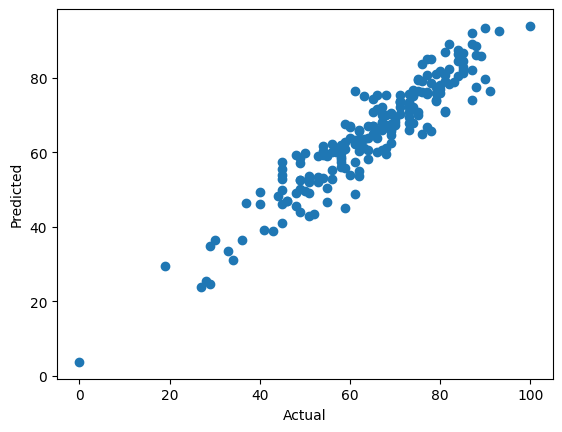

In [42]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

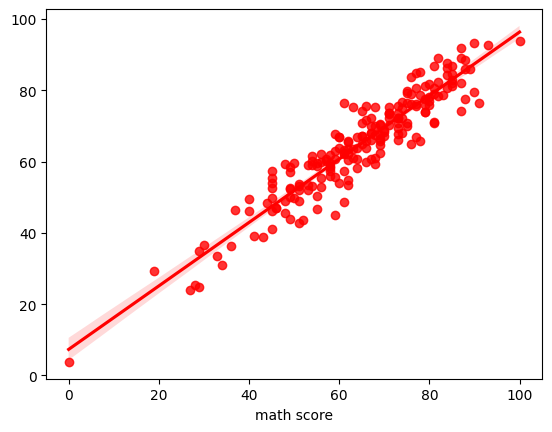

In [43]:
sns.regplot(x=y_test,y=y_pred,color='red')
plt.show()

Differnce Between Actual And Predicted Values

In [44]:
pred_df = pd.DataFrame({"Actual Value":y_test,"Predicted Value":y_pred,"Difference":y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.507812,14.492188
737,53,58.953125,-5.953125
740,80,76.960938,3.039062
660,74,76.757812,-2.757812
411,84,87.539062,-3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,-0.031250
208,74,67.976562,6.023438
613,65,67.132812,-2.132812
